In [2]:
import sys
sys.path.append("..")

from src.data_loader import load_raw_data

## Data Loading

1. Load data and reveal the first few columns.

In [10]:
df = load_raw_data()
df.head()

Loaded data via local (30000 rows, 25 columns).


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Data Audit

2. Shape of data - how many rows and columns.

In [15]:
print(df.shape)


(30000, 25)


3. Dtypes - what does pandas think each column is?

In [19]:
print(df.dtypes.value_counts())
df.dtypes

float64    13
int64      12
Name: count, dtype: int64


ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object

4. Nulls 

In [17]:
print(df.isnull().sum().sum())

0


5. For every column that's supposed to represent a fixed set of categories (even if its stored as an integer, like EDUCATION) - check `value_counts()` and compare against expected valid values, according to the codebook/documentation

In [18]:
print(df["EDUCATION"].value_counts())
print(df["MARRIAGE"].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


6. For every numeric column check `describe()` for obviously impossible values (negative ages, ages of 200, negative bill amounts that shouldn't be negative etc)

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [9]:
df["EDUCATION"]

0        2
1        2
2        2
3        2
4        2
        ..
29995    3
29996    3
29997    2
29998    3
29999    2
Name: EDUCATION, Length: 30000, dtype: int64

7. Check duplicates and values of specific columns

In [25]:
print(df.duplicated().sum())

for col in ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
    print(df[col].value_counts().sort_index())
    print()

0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64



The official dataset documentation defines PAY_* as: -1 = pay duly, 1 = payment delay 1 month, 2 = delay 2 months, ... 8 = delay 8 months and above. The documentation never defines what 0 or -2 mean.

The widely-accepted interpretation among people who've worked with this exact dataset (including discussion around the original paper) is:

- -1 = paid duly (on time)
- 0 = likely means "paid, but with revolving/minimum-only balance" or simply "no delay recorded" — not officially documented, but far too common and evenly distributed to be an error
- -2 = likely "no consumption / no bill that month" (i.e., the account had no transaction to be late or on time about)
- 1–8 = documented, delay in months

## EDA

1. Target Imbalance 

In [32]:
import matplotlib.pyplot as plt

target_counts = df['default.payment.next.month'].value_counts()
target_pct = df['default.payment.next.month'].value_counts(normalize=True)*100

print("Target variable counts:", target_counts)
print("Pct of target variable:", target_pct)


Target variable counts: default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
Pct of target variable: default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


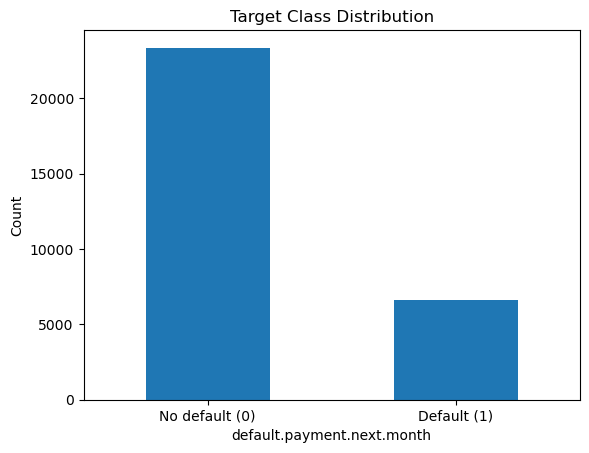

In [38]:
target_counts.plot(kind='bar')
plt.xticks([0,1], ['No default (0)', 'Default (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Target Class Distribution')
plt.show()

The taget variable `default.payment.next.month` is imbalanced: 23,364 clients (77.88%) did not default while 6,636 clients(22.12%) did - roughly a 3.5:1 ratio of non-default to default.

This has direct implications for the rest if the project:

1. Accurracy is not reliable metric . A model that predicts "no default" for every client would score ~77.88% accuracy while being completely useless - it would never catch a single actual defaulter. This is why precision, recall, F1 and ROC-AUC are the metrics that matter here: they specifically capture how well the model identifies the minority (default) class, rather than reqarding it for defaulting to minority.

2. Class imbalance needs to be addressed during modeling, not just measured here. Options to consider later include class weighting (penalizing misclassification of minority class more heavily) or resampling techniques (e.g SMOTE). The decision on which approach to use will be made in the modeling phase, but the imbalance identified here is why that decision is necessary.

The 77.88% acts as a reference point; its the score a base/naive/trivia classifier would get, and any real model built needs to be evaluated against more than that number alone to be meaningful.

2. Numeric Feature Distributions


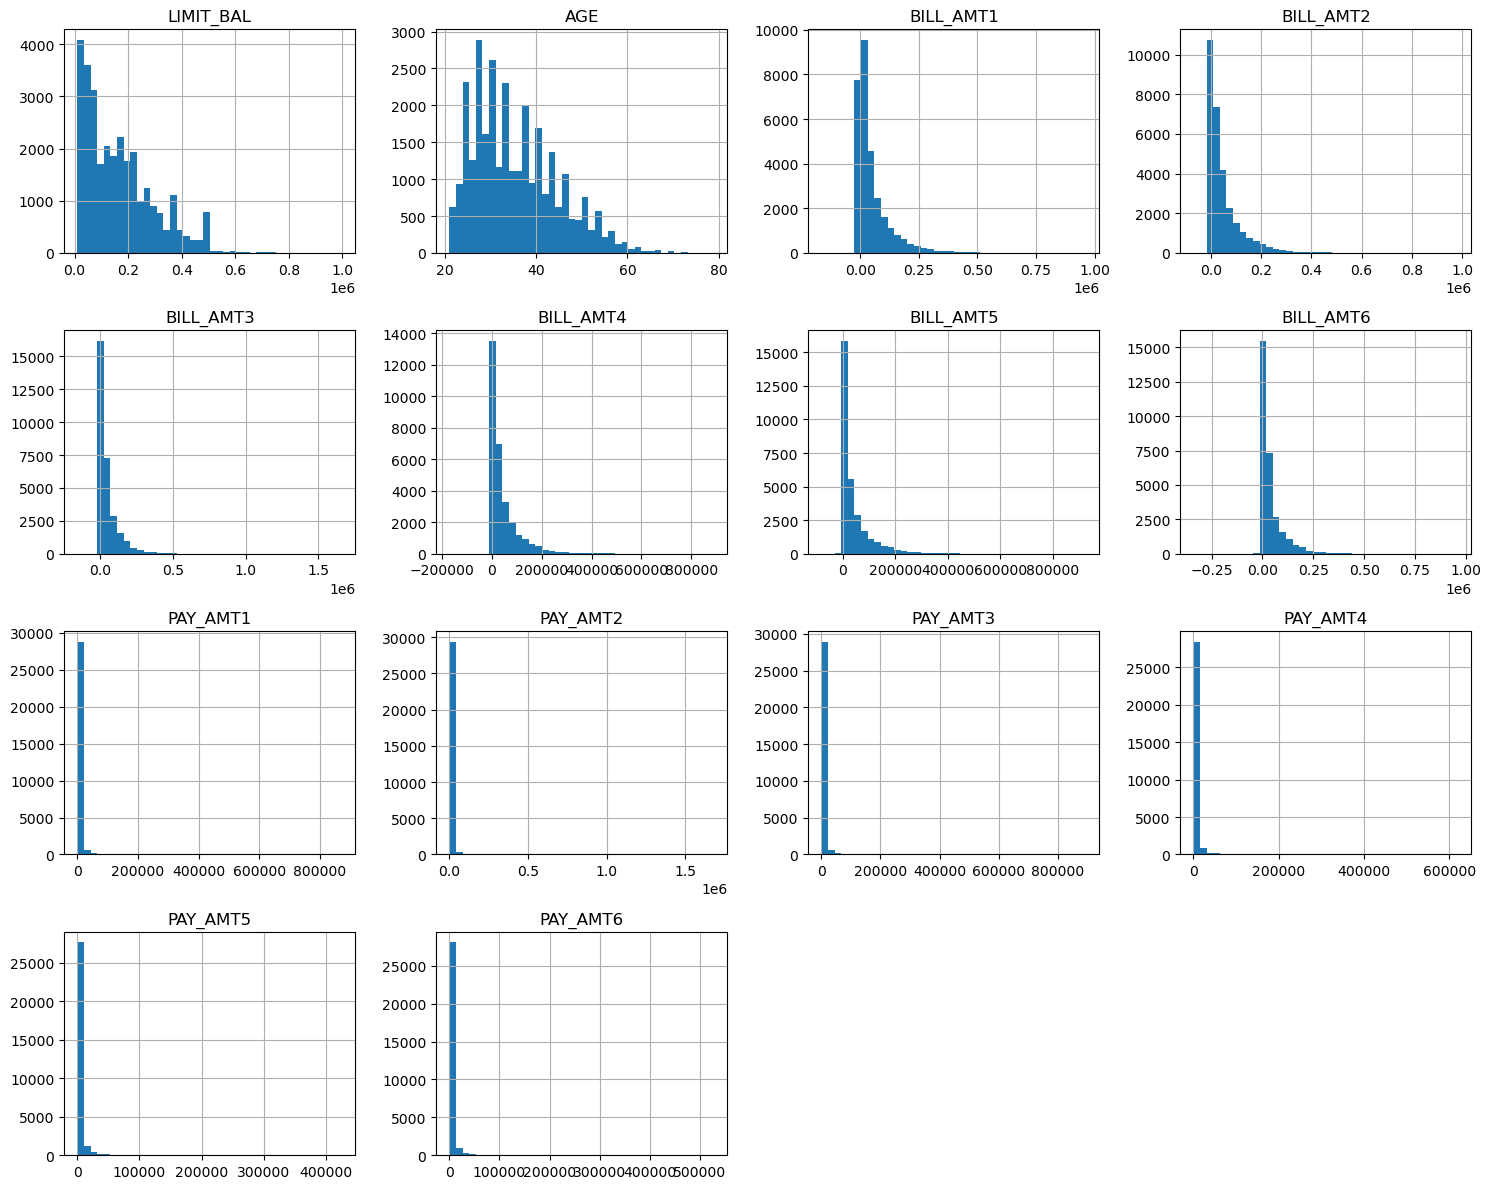

In [43]:
num_cols = ['LIMIT_BAL', 'AGE'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)]

df[num_cols].hist(figsize=(15,12), bins=40)
plt.tight_layout()
plt.show()